# Flight Fare Prediction

# TASK - 1

## Bussines Case
We have to analyze the flight fare prediction using Machine Learning dataset using
essential exploratory data analysis techniques then will draw some predictions about
the price of the flight based on some features such as what type of airline it is, what is
the arrival time, what is the departure time, what is the duration of the flight, source,
destination and more


## Domain Analysis

* **Data Shape** : The data has 10 quantitative input varaibles and 1 quantitative varaibale. i.e 10683instances(observations).
* **Categorical_columns** : Airline, Source , Destination , Route ,Additional_Info.
* **Date&Time_columns** : Date_of_journey , Dep_Time , Arrival_Time , Duration .
* **Numerical_columns** : Total_stops , Price .    

## Data Attributes

1. **Airline**: So this column will have all the types of airlines like Indigo, Jet Airways,
Air India, and many more.
2. **Date_of_Journey**: This column will let us know about the date on which the
passenger’s journey will start.
3. **Source**: This column holds the name of the place from where the passenger’s
journey will start.
4. **Destination**: This column holds the name of the place to where passengers
wanted to travel.
5. **Route**: Here we can know about what the route is through which passengers
have opted to travel from his/her source to their destination.
6. **Arrival_Time**: Arrival time is when the passenger will reach his/her destination.
7. **Dep_Time**: Departure time is when the passenger will attend his/her flight.
8. **Duration**: Duration is the whole period that a flight will take to complete its
journey from source to destination.
9. **Total_Stops**: This will let us know in how many places flights will stop there for
the flight in the whole journey.
10. **Additional_Info**: In this column, we will get information about food, kind of food,
and other amenities.
11. **Price**: Price of the flight for a complete journey including all the expenses
before onboarding.    

## Project Process Steps:
1. **Importing all the neccesary libraries**
2. **Understanding the data/ Insights from data**
3. **Exploratory Data Analysis (EDA)**
4. **Data Pre-processing**
5. **Feature Selection**
6. **Model Creation and Evaluation**
7. **Conclusion**

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## Understanding The Data

In [2]:
data = pd.read_excel('Flight_Fare.xlsx')

In [3]:
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


## Basic Checks

In [4]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [5]:
data.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [6]:
data.describe()# shows the mean,std,min,25%,50%,75% of numerical columns

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [7]:
data.describe(include='O')# shows the unique,mode,mode_frequency of categorical data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683
unique,12,44,5,6,128,222,1343,368,5,10
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info
freq,3849,504,4537,4537,2376,233,423,550,5625,8345


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [9]:
data['Journey_day'] = pd.to_datetime(data.Date_of_Journey, format = '%d/%m/%Y').dt.day # creating of new column for journey day

data['Journey_month'] = pd.to_datetime(data.Date_of_Journey, format = '%d/%m/%Y').dt.month # creating of new column for journey month

data.drop(['Date_of_Journey'],axis=1,inplace=True) # dropping of Date_of_Journey because we have created the day,month column

In [10]:
data['Dep_hour'] = pd.to_datetime(data.Dep_Time).dt.hour # creating of new column for Dep_hour

data['Dep_min'] = pd.to_datetime(data.Dep_Time).dt.minute # creating of new column for Dep_min

data.drop(['Dep_Time'],axis=1,inplace=True) # dropping of Dep_time as we have created new columns

In [11]:
data['Arrival_hour'] = pd.to_datetime(data.Arrival_Time).dt.hour # creating of new column for arrival_hour

data['Arrival_min'] = pd.to_datetime(data.Arrival_Time).dt.minute # craeting of new column for arrival_min

data.drop(['Arrival_Time'],axis=1,inplace=True) # dropping of Arrival_time as we have created new column

In [12]:
duration = list(data['Duration'])

In [13]:
for i in range(len(duration)):
    if len(duration[i].split()) != 2:
        if "h" in duration[i]:
            duration[i] = duration[i].strip() + " 0m"
        else:
            duration[i] = "0h " + duration[i]

duration_hours = []
duration_mins = []
for i in range(len(duration)):
    duration_hours.append(int(duration[i].split(sep = "h")[0]))
    duration_mins.append(int(duration[i].split(sep = "m")[0].split()[-1]))

In [14]:
data['Duration_hours'] = duration_hours # creating of new column of duration_hours

data['Duration_mins'] = duration_mins # creating of new column of duration_min

data.drop(['Duration'],axis=1,inplace=True) # dropping of Duration as we have created new columns

In [15]:
data # data after creating new columns

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,non-stop,No info,4107,9,4,19,55,22,25,2,30
10679,Air India,Kolkata,Banglore,CCU → BLR,non-stop,No info,4145,27,4,20,45,23,20,2,35
10680,Jet Airways,Banglore,Delhi,BLR → DEL,non-stop,No info,7229,27,4,8,20,11,20,3,0
10681,Vistara,Banglore,New Delhi,BLR → DEL,non-stop,No info,12648,1,3,11,30,14,10,2,40


## Exploratory Data Analysis

### Univariate Analysis

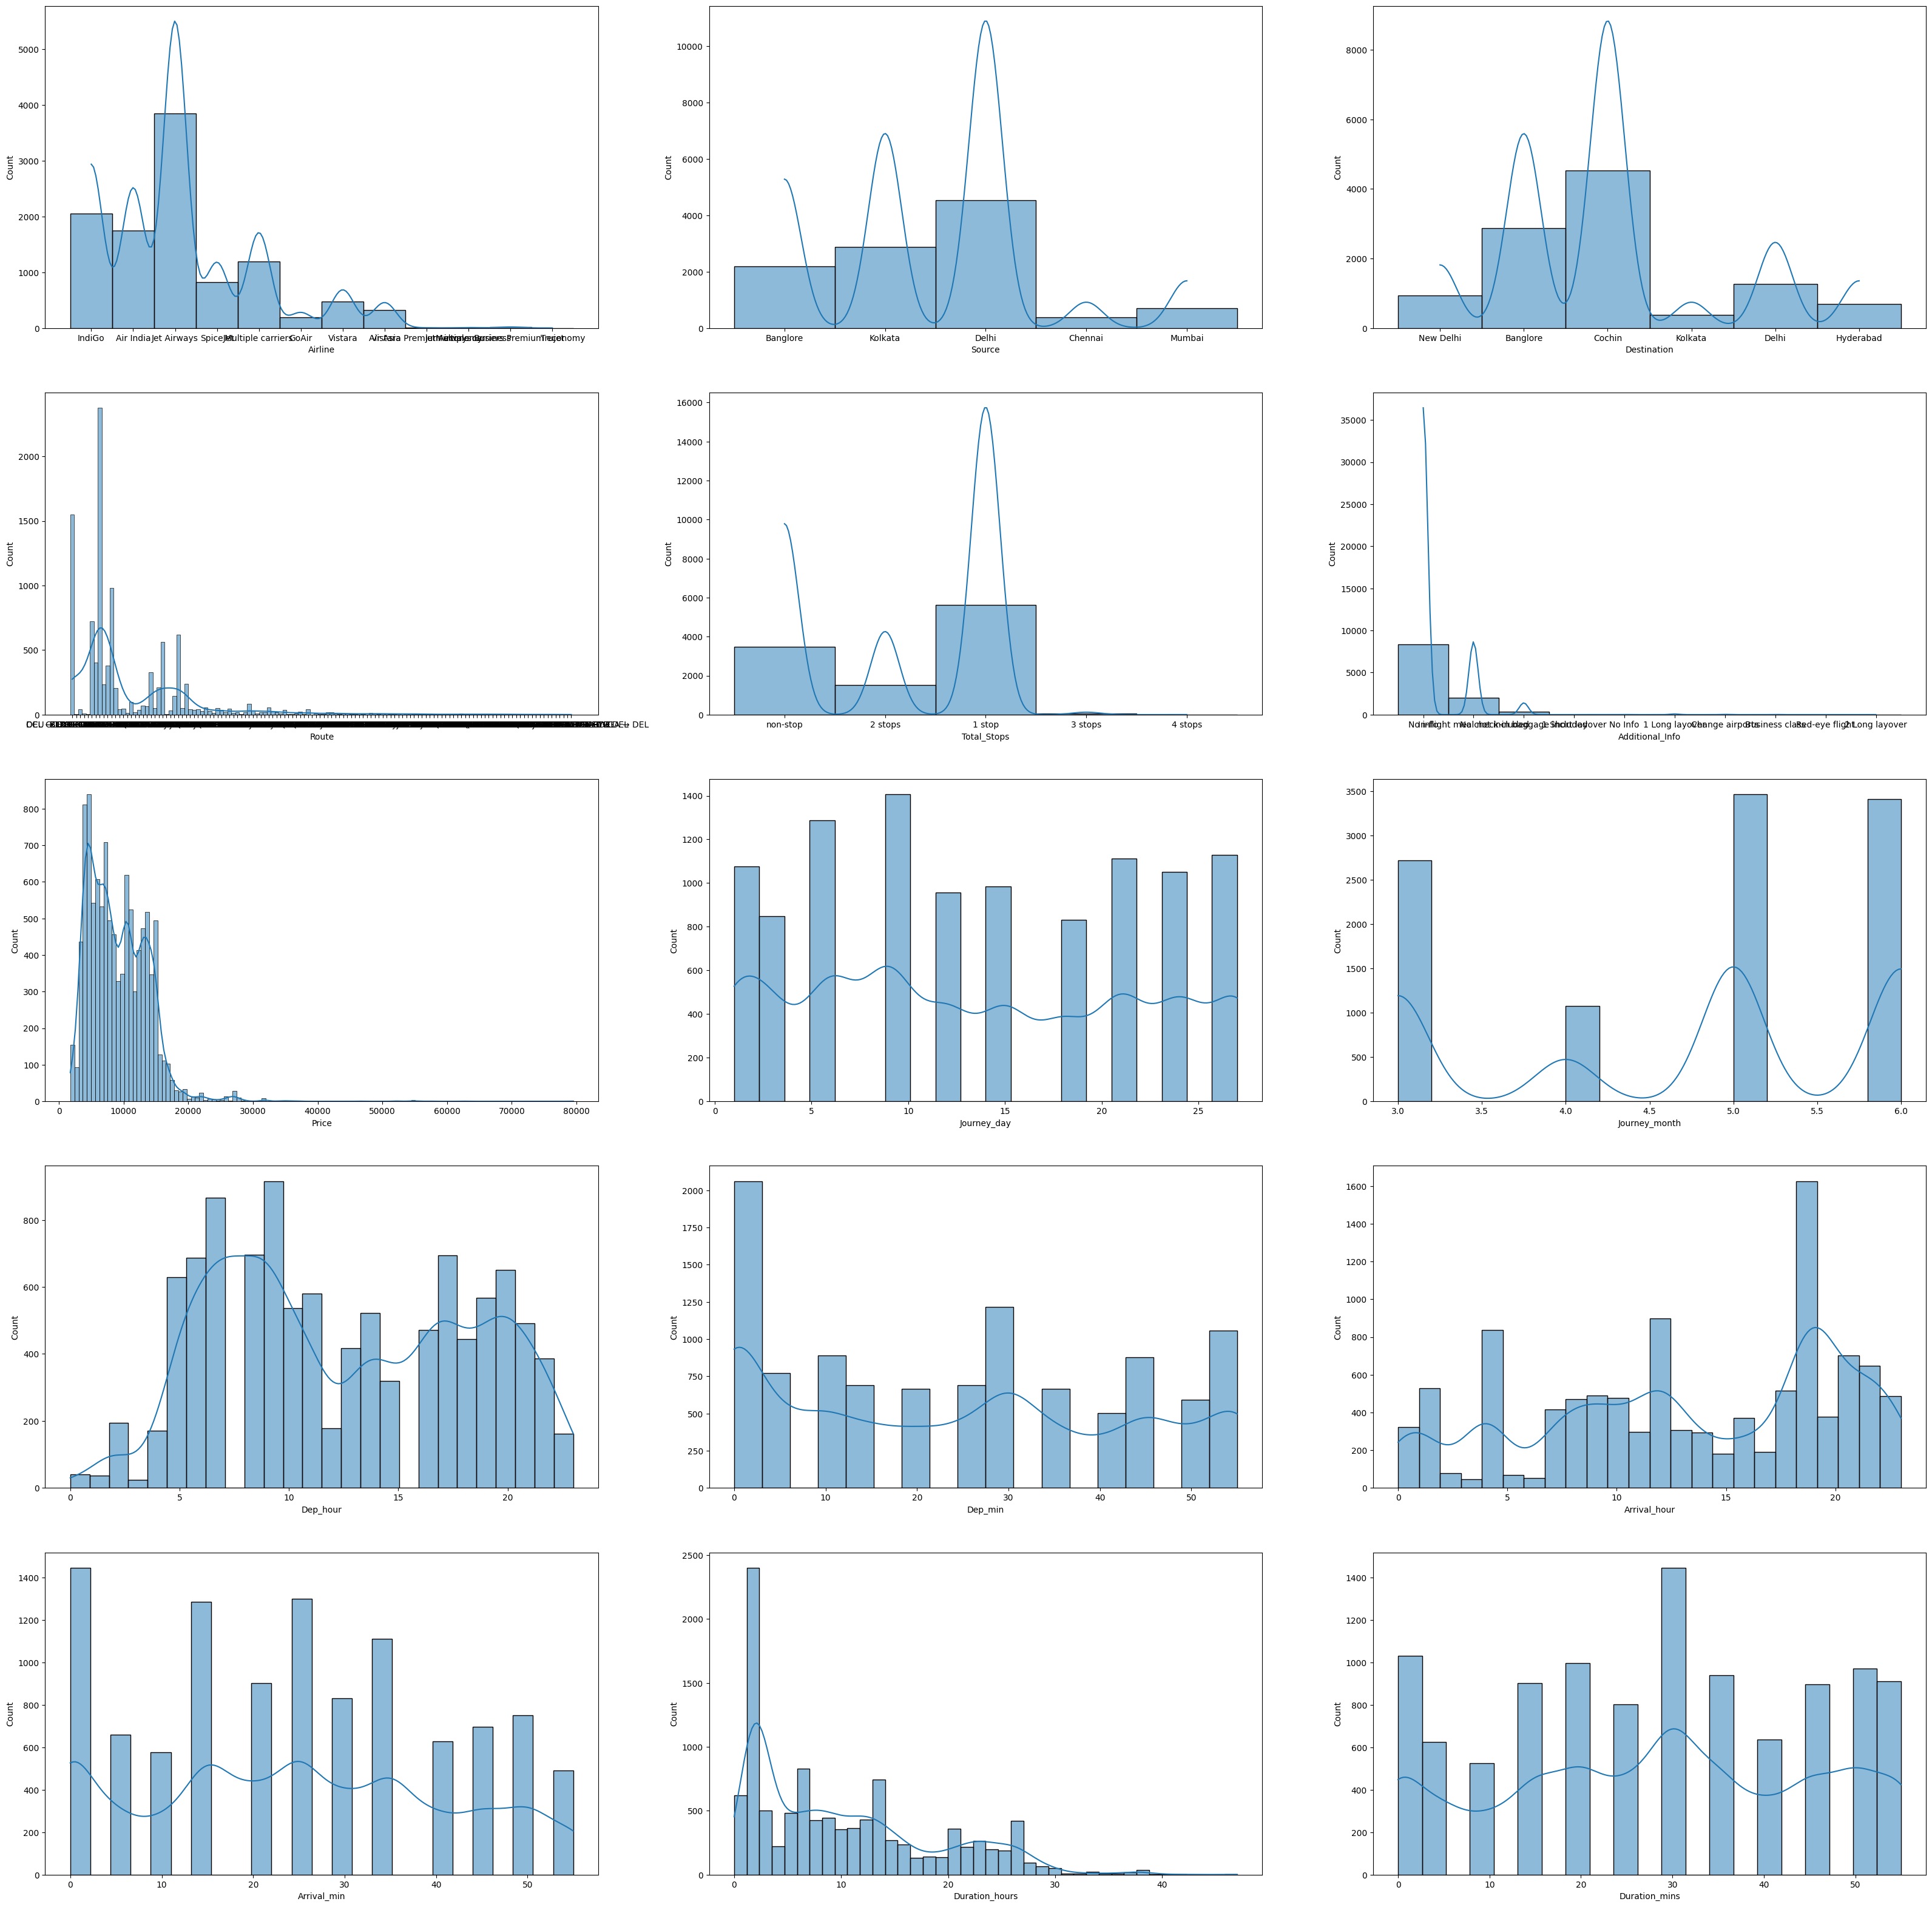

In [16]:
plt.figure(figsize=(40,40),facecolor='white')
pltno=1

for col in data:
  if pltno<=15:
    ax=plt.subplot(5,3,pltno)
    sns.histplot(x=data[col],kde=True)
  pltno+=1
plt.show()


**INSIGHTS**

1. There are more datapoints in JetAirways followed by Indigo & AirIndia.
2. From Delhi the more number of flights has taken off followed by Kolkata & Banglore.
3. The Cochin has more arrivals followed by Banglore & Delhi.
4. Mostly the flights are connecting and it has one stop followed by direct & 2 stop flights.
5. We can see most of the flights were operating in the month of may & june.
6. The flights with 2 hours duration are more when compared to the other flying hours.

### Bivariant Analysis

In [ ]:
plt.figure(figsize=(40,40),facecolor='white')
pltno=1

for col in data:
  if pltno<=15:
    ax=plt.subplot(5,3,pltno)
    sns.barplot(x=data[col],y=data['Price'])
    plt.xticks(rotation='vertical')
  pltno+=1
plt.show()

**INSIGHTS**

1. For all the airlines the flight fares are almost similar for economy class except for the jet airways business class.
2. Flights flying from Delhi, Kolkata & Banglore are almost double compared to Chennai & Mumbai.
3. Flights with 4 stops have higher fare when compared to other flights.
4. Flights in the month of April have cheaper fares when compared to other months.
5. Flights with 47 flying hours are costlier compared to other time duration.

### Multivariant Analysis

In [ ]:
sns.pairplot(data)

## Data Preprocessing

In [ ]:
data.drop(['Route','Additional_Info'],axis=1,inplace=True) # dropping of columns as if the are not use full for fligh fare prediction

In [ ]:
data.isnull().sum() # seeing for null values

In [ ]:
data.dropna(inplace=True) # dropping of null value

In [ ]:
data.duplicated().sum() # seeing for duplicated values

In [ ]:
data.drop_duplicates(inplace=True) # Dropping of duplicate values

### Encoding of categorical data

In [ ]:
data.Airline.unique()

In [ ]:
data['Airline'] = data['Airline'].map({'IndiGo':0, 'Air India':1, 'Jet Airways':2, 'SpiceJet':3,
       'Multiple carriers':4, 'GoAir':5, 'Vistara':6, 'Air Asia':7,
       'Vistara Premium economy':8, 'Jet Airways Business':9,
       'Multiple carriers Premium economy':10, 'Trujet':11})

In [ ]:
data.Source.unique()

In [ ]:
data['Source'] = data['Source'].map({'Banglore':0, 'Kolkata':1, 'Delhi':2, 'Chennai':3, 'Mumbai':4})

In [ ]:
data.Destination.unique()

In [ ]:
data['Destination'] = data['Destination'].map({'New Delhi':0, 'Banglore':1, 'Cochin':2, 'Kolkata':3, 'Delhi':0, 'Hyderabad':5})

In [ ]:
data.Total_Stops.unique()

In [ ]:
data['Total_Stops'] = data['Total_Stops'].map({'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4})

In [ ]:
data # data after encoding the columns

### Outliers Handling

In [ ]:
plt.figure(figsize=(40,40),facecolor='white')
pltno=1

for col in data:
    if pltno<=15:
        ax=plt.subplot(5,3,pltno)
        sns.boxplot(x=data[col])
    pltno+=1
plt.show()

# Removing outliers

In [ ]:
for column in data:
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_limit = Q1 - 1.5*IQR
  upper_limit = Q3 + 1.5*IQR
  data.loc[data[column]<lower_limit,column]=data[column].median()
  data.loc[data[column]>upper_limit,column]=data[column].median()

In [ ]:
plt.figure(figsize=(40,40),facecolor='white')
pltno=1

for col in data:
    if pltno<=15:
        ax=plt.subplot(5,3,pltno)
        sns.boxplot(x=data[col])
    pltno+=1
plt.show()

### Scaling The Data

In [ ]:
scale = MinMaxScaler()

df1 = scale.fit_transform(data.drop('Price',axis=1))

In [ ]:
data.columns

In [ ]:
df = pd.DataFrame(df1,columns=['Airline', 'Source', 'Destination', 'Total_Stops',
       'Journey_day', 'Journey_month', 'Dep_hour', 'Dep_min', 'Arrival_hour',
       'Arrival_min', 'Duration_hours', 'Duration_mins'])

In [ ]:
df

## Feature Selection

In [ ]:
plt.figure(figsize=(20,20),facecolor='white')
sns.heatmap(df.corr(),annot=True)

In [ ]:
df.drop('Source',inplace=True,axis=1) # Dropping of Source column as it is highly correlated.

# TASK - 2

## Model Creation

In [ ]:
x = df
y = data['Price']

In [ ]:
x_train , x_test, y_train,y_test = train_test_split(x,y,random_state=42)

In [ ]:
def adjusted_r_squared(r_squared, n, p):
    """
    Calculate the adjusted R-squared score.

    Parameters:
        r_squared (float): The R-squared score.
        n (int): Number of samples.
        p (int): Number of predictors.

    Returns:
        float: The adjusted R-squared score.
    """
    adjusted_r2 = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)
    return adjusted_r2

def run_multiple_algorithms(x_train, y_train, x_test, y_test, models):
    results = {}

    for model_name, model in models.items():
        # Train the model
        model.fit(x_train, y_train)

        # Make predictions
        y_pred = model.predict(x_test)

        # Calculate r2_score, mae & mse
        r2_score_value = r2_score(y_test, y_pred)
        mean_absolute_error_value = mean_absolute_error(y_test, y_pred)
        mean_squared_error_value = mean_squared_error(y_test, y_pred)

        # Calculate adjusted r2_score
        n = len(y_test)
        p = x_test.shape[1]
        adjusted_r2_score = adjusted_r_squared(r2_score_value, n, p)

        # Store results in the dictionary
        results[model_name] = {
            'r2_score': r2_score_value,
            'mae': mean_absolute_error_value,
            'mse': mean_squared_error_value,
            'rmse': np.sqrt(mean_squared_error_value),
            'adjusted_r2': adjusted_r2_score
        }

    return results

# Define the models to run
model_to_run = {
    'LinearRegression': LinearRegression(),
    'k-Neighbours Regressor': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'RandomForestRegressor': RandomForestRegressor(),
    'XGBRegressor': XGBRegressor()
}

# Run the models
results = run_multiple_algorithms(x_train, y_train, x_test, y_test, model_to_run)

# Print the results
for model, scores in results.items():
    print(f"Model: {model}")
    print(f"r2_score: {scores['r2_score']}")
    print(f"Adjusted r2_score: {scores['adjusted_r2']}")
    print(f"mean_absolute_error: {scores['mae']}")
    print(f"mean_squared_error: {scores['mse']}")
    print(f"Root Mean Squared Error (RMSE): {scores['rmse']}")
    print('=' * 30)

# Model Comparison Report

In [ ]:
pd.DataFrame(results).T

## Applying Hyperparameters (RandomizedSearchCV)

In [ ]:
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 15, 100],
    'min_samples_leaf': [1, 2, 5, 10]
}

# Create the RandomForestRegressor model
rf_model = RandomForestRegressor()

# Instantiate the RandomizedSearchCV object
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid, cv=5)

# Fit the model to the training data
random_search.fit(x_train, y_train)

# Get the best hyperparameters
best_params = random_search.best_params_

# Print the best hyperparameters
print("Best hyperparameters:", best_params)

# Train the model with the best hyperparameters
rf_model_best = RandomForestRegressor(**best_params)
rf_model_best.fit(x_train, y_train)

# Evaluate the model on the test data
y_pred_best = rf_model_best.predict(x_test)

# Calculate the performance metrics
r2_score_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)

# Print the performance metrics
print("r2_score:", r2_score_best)
print("mean_absolute_error:", mae_best)
print("mean_squared_error:", mse_best)
print("Root Mean Squared Error (RMSE):", rmse_best)


# Reports on Challenges Faced

* Creating of new columns for date and time columns using to_datetime function.
* Encoding of categorical data to numerical data using map function.
* Applying of hyperparams for RandomforestRegressor using RandomizedSearchCV.